<a href="https://colab.research.google.com/github/Arif0000/Pytorch/blob/main/Linear_Regression_with_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [21]:
x_train = np.array([[3.3], [4.4], [5.5], [6.71], [6.93], [4.168],
                    [9.779], [6.182], [7.59], [2.167], [7.042],
                    [10.791], [5.313], [7.997], [3.1]], dtype=np.float32)

y_train = np.array([[1.7], [2.76], [2.09], [3.19], [1.694], [1.573],
                    [3.366], [2.596], [2.53], [1.221], [2.827],
                    [3.465], [1.65], [2.904], [1.3]], dtype=np.float32)

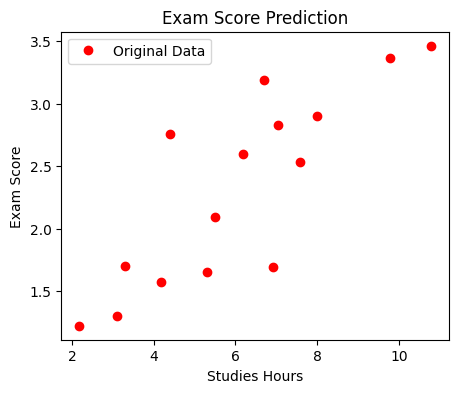

In [22]:
fig = plt.figure(figsize=(5,4))
plt.plot(x_train,y_train,'ro', label='Original Data')
plt.xlabel("Studies Hours")
plt.ylabel('Exam Score')
plt.legend()
plt.title('Exam Score Prediction')
plt.show()

In [23]:
x_train = torch.from_numpy(x_train)
y_train = torch.from_numpy(y_train)

x_train, y_train


(tensor([[ 3.3000],
         [ 4.4000],
         [ 5.5000],
         [ 6.7100],
         [ 6.9300],
         [ 4.1680],
         [ 9.7790],
         [ 6.1820],
         [ 7.5900],
         [ 2.1670],
         [ 7.0420],
         [10.7910],
         [ 5.3130],
         [ 7.9970],
         [ 3.1000]]),
 tensor([[1.7000],
         [2.7600],
         [2.0900],
         [3.1900],
         [1.6940],
         [1.5730],
         [3.3660],
         [2.5960],
         [2.5300],
         [1.2210],
         [2.8270],
         [3.4650],
         [1.6500],
         [2.9040],
         [1.3000]]))

In [24]:
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(1,1)
  def forward(self,x):
    out=self.linear(x)
    return out

In [25]:
model = LinearRegression()

In [26]:
model

LinearRegression(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

In [27]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[-0.7170]])),
             ('linear.bias', tensor([-0.0968]))])

In [28]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.7170]], requires_grad=True),
 Parameter containing:
 tensor([-0.0968], requires_grad=True)]

In [29]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

In [36]:
num_epochs = 1000

In [37]:
for epoch in range(num_epochs):
  model.train()
  out=model(x_train)
  loss=criterion(out, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if (epoch + 1) % 100 ==0:
    print(f"epoch [{epoch + 1} / {num_epochs}], loss : {loss.item():.6f}")

epoch [100 / 10000], loss : 0.227848
epoch [200 / 10000], loss : 0.227546
epoch [300 / 10000], loss : 0.227245
epoch [400 / 10000], loss : 0.226947
epoch [500 / 10000], loss : 0.226649
epoch [600 / 10000], loss : 0.226353
epoch [700 / 10000], loss : 0.226059
epoch [800 / 10000], loss : 0.225766
epoch [900 / 10000], loss : 0.225475
epoch [1000 / 10000], loss : 0.225185
epoch [1100 / 10000], loss : 0.224897
epoch [1200 / 10000], loss : 0.224610
epoch [1300 / 10000], loss : 0.224325
epoch [1400 / 10000], loss : 0.224041
epoch [1500 / 10000], loss : 0.223759
epoch [1600 / 10000], loss : 0.223478
epoch [1700 / 10000], loss : 0.223198
epoch [1800 / 10000], loss : 0.222920
epoch [1900 / 10000], loss : 0.222643
epoch [2000 / 10000], loss : 0.222368
epoch [2100 / 10000], loss : 0.222094
epoch [2200 / 10000], loss : 0.221822
epoch [2300 / 10000], loss : 0.221551
epoch [2400 / 10000], loss : 0.221281
epoch [2500 / 10000], loss : 0.221013
epoch [2600 / 10000], loss : 0.220746
epoch [2700 / 10000],

In [38]:
model.eval()
with torch.no_grad():
  prediction = model(x_train)
prediction.data.numpy()

array([[1.3322476],
       [1.7004448],
       [2.0686421],
       [2.473659 ],
       [2.5472984],
       [1.6227888],
       [3.5009294],
       [2.296924 ],
       [2.7682166],
       [0.9530045],
       [2.5847874],
       [3.8396707],
       [2.0060487],
       [2.9044495],
       [1.2653027]], dtype=float32)

In [39]:
y_train


tensor([[1.7000],
        [2.7600],
        [2.0900],
        [3.1900],
        [1.6940],
        [1.5730],
        [3.3660],
        [2.5960],
        [2.5300],
        [1.2210],
        [2.8270],
        [3.4650],
        [1.6500],
        [2.9040],
        [1.3000]])

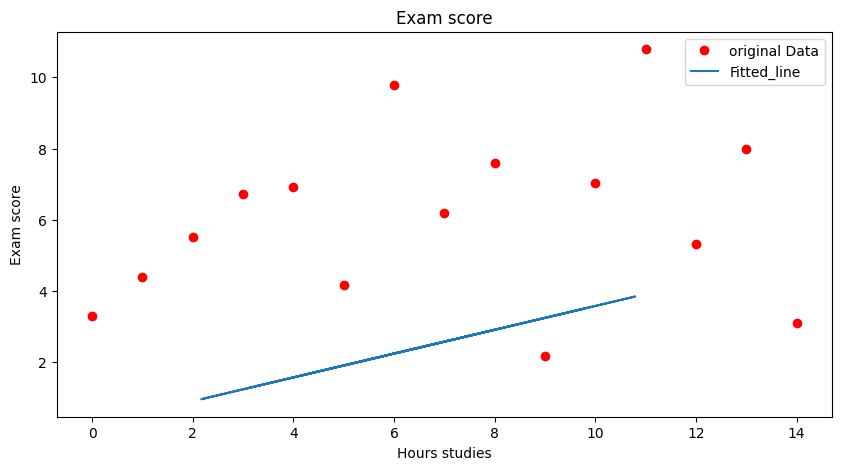

In [40]:
fig = plt.figure(figsize=(10,5))
plt.plot(x_train.numpy(), 'ro', label='original Data')
plt.plot(x_train.numpy(), prediction, label='Fitted_line')
plt.xlabel("Hours studies")
plt.ylabel("Exam score")
plt.legend()
plt.title('Exam score')
plt.show()

In [41]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[0.3347]])),
             ('linear.bias', tensor([0.2277]))])

In [42]:
new_hours_studies = 8.0
new_hours_tensor = torch.tensor([[new_hours_studies]], dtype=torch.float32)

In [45]:
model.eval()
with torch.no_grad():
  new_exam_score = model(new_hours_tensor)
print('predicted exam score', new_exam_score.item())

predicted exam score 2.905453681945801


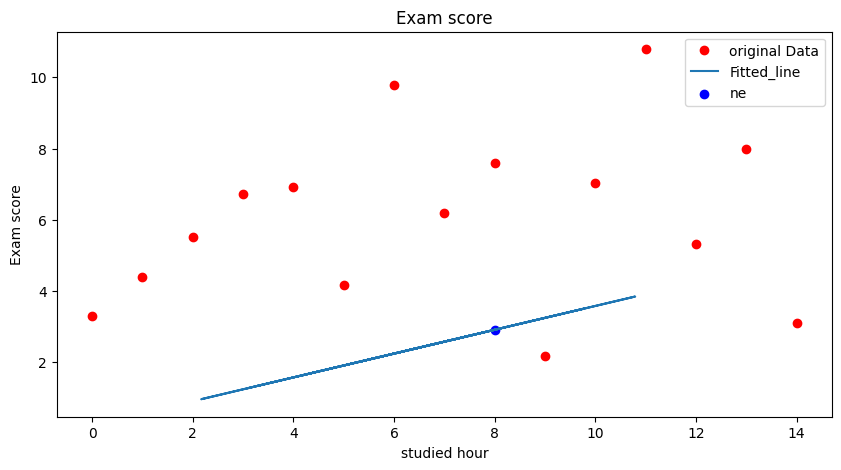

In [48]:
fig = plt.figure(figsize=(10,5))
plt.plot(x_train.numpy(), 'ro', label='original Data')
plt.plot(x_train.numpy(), prediction, label='Fitted_line')
plt.scatter([new_hours_studies],[new_exam_score.item()], color='blue', label="ne")
plt.xlabel('studied hour')
plt.ylabel("Exam score")
plt.legend()
plt.title('Exam score')
plt.show()

In [49]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[0.3347]])),
             ('linear.bias', tensor([0.2277]))])

In [50]:
torch.save(model.state_dict(),'./Linearrehression.pth')